In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [77]:
df = pd.read_csv('data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [78]:
# numeric cols

data = df.drop(columns=['country']).copy()
data.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## KNN

In [79]:
# train test split (80/20)

def train_test_split(X, y, test_size=0.2, random_state=1):
	rng = np.random.RandomState(random_state)
	idx = np.arange(X.shape[0])
	rng.shuffle(idx)
	split = int(X.shape[0] * (1 - test_size))
	train_idx, test_idx = idx[:split], idx[split:]

	return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

In [80]:
# scaler

class StandardScaler:
	def fit(self, X):
		self.mean_ = X.mean(axis=0)
		self.std_ = X.std(axis=0, ddof=0)
		self.std_[self.std_ == 0] = 1.0
	
	def transform(self, X):
		return (X - self.mean_) / self.std_
	
	def fit_transform(self, X):
		self.fit(X)
		return self.transform(X)

In [81]:
# distance

def euclidean_distances(X_train, x_query):
	diff = X_train - x_query
	return np.sqrt(np.sum(diff**2, axis=1))

In [82]:
# KNN predict

def knn_predict_regression(X_train, y_train, X_test, k=5):
	preds = []
	
	for x in X_test:
		dists = euclidean_distances(X_train, x)
		nn_idx = np.argsort(dists)[:k]
		preds.append(np.mean(y_train[nn_idx]))
	
	return np.array(preds)

def knn_predict_classification(X_train, y_train, X_test, k=5):
	preds = []

	for x in X_test:
		dists = euclidean_distances(X_train, x)
		nn_idx = np.argsort(dists)[:k]
		votes = y_train[nn_idx]
		most_common = Counter(votes).most_common()
		preds.append(most_common[0][0])

	return np.array(preds)

### KNN regression

In [83]:
target = 'life_expec'
X = data.drop(columns=target).values
y_reg = data[target].values.astype(float)

In [84]:
# split

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.25, random_state=67)

In [85]:
# scale

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
# errors

def rmse(a, b):
	return np.sqrt(np.mean(a - b) ** 2)

def mae(a, b):
	return np.mean(np.abs(a - b))

In [87]:
# find best k by accuracy (1..15)

ks = list(range(1, 16))
rmse_vals = []
mae_vals = []

for k in ks:
	pred = knn_predict_regression(X_train_scaled, y_train_reg, X_test_scaled, k=k)
	rmse_vals.append(rmse(pred, y_test_reg))
	mae_vals.append(mae(pred, y_test_reg))

best_k = ks[int(np.argmin(rmse_vals))]
best_rmse = min(rmse_vals)
print(f"Best k by RMSE: {best_k} (RMSE={best_rmse:.3f})")

Best k by RMSE: 2 (RMSE=0.373)


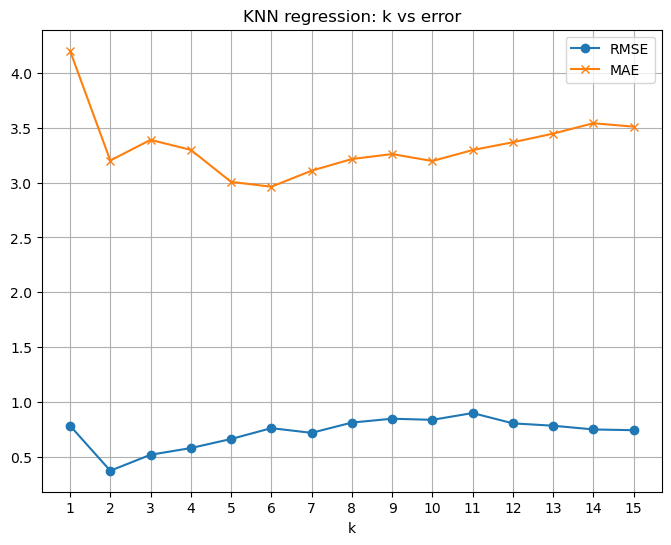

In [88]:
# plot k vs error

plt.figure(figsize=(8,6))
plt.plot(ks, rmse_vals, marker='o', label='RMSE')
plt.plot(ks, mae_vals, marker='x', label='MAE')
plt.xlabel('k')
plt.xticks(ks)
plt.title('KNN regression: k vs error')
plt.legend()
plt.grid(True)

plt.show()

In [89]:
# evaluate metrics

pred_best = knn_predict_regression(X_train_scaled, y_train_reg, X_test_scaled, k=best_k)
print("Regression metrics on test split:")

# RMSE and MAE
print(f"RMSE: {rmse(pred_best, y_test_reg):.3f}")
print(f"MAE: {mae(pred_best, y_test_reg):.3f}")

# R2 score
ss_res = np.sum((y_test_reg - pred_best)**2)
ss_tot = np.sum((y_test_reg - np.mean(y_test_reg))**2)
r2 = 1 - ss_res/ss_tot
print(f"R2 score: {r2:.3f}")

Regression metrics on test split:
RMSE: 0.373
MAE: 3.201
R2 score: 0.682


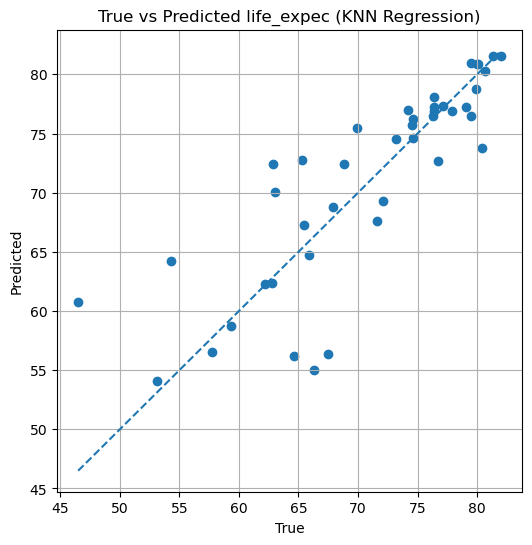

In [90]:
# true vs predicted plot

plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, pred_best)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], linestyle='--')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('True vs Predicted life_expec (KNN Regression)')
plt.grid(True)

plt.show()

### KNN classification

In [91]:
# create binary label using median

median_le = np.median(y_reg)
y_class = (y_reg >= median_le).astype(int) # 0: low life expectancy, 1: high

In [92]:
# train test split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.25, random_state=67)

In [93]:
# scale

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

In [94]:
# find best k by accuracy (1..15)

ks = list(range(1, 16))
accs = []

for k in ks:
	pred_c = knn_predict_classification(X_train_c_scaled, y_train_c, X_test_c_scaled, k=k)
	acc = (pred_c == y_test_c).mean()
	accs.append(acc)

best_k_c = ks[int(np.argmax(accs))]
best_acc = max(accs)
print(f"Classification: best k by accuracy = {best_k_c} (accuracy={best_acc:.3f})")

Classification: best k by accuracy = 3 (accuracy=0.976)


In [97]:
# evaluate metrics

def accuracy(y_true, y_pred):
	return (y_true == y_pred).mean()

def confusion_matrix(y_true, y_pred):
	tp = np.sum((y_true == 1) & (y_pred == 1))
	fp = np.sum((y_true == 0) & (y_pred == 1))
	tn = np.sum((y_true == 0) & (y_pred == 0))
	fn = np.sum((y_true == 1) & (y_pred == 0))
	return np.array([[tn, fp], [fn, tp]])

def f1(y_true, y_pred, pos_class):
	tp = np.sum((y_true == pos_class) & (y_pred == pos_class))
	fp = np.sum((y_true != pos_class) & (y_pred == pos_class))
	fn = np.sum((y_true == pos_class) & (y_pred != pos_class))

	precision = tp / (tp + fp) if (tp + fp) != 0 else 0
	recall = tp / (tp + fn) if (tp + fn) != 0 else 0
	f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0

	return precision, recall, f1

def classification_report(y_true, y_pred):
	cm = confusion_matrix(y_true, y_pred)
	tn, fp = cm[0]
	fn, tp = cm[1]

	print("Confusion Matrix:")
	print(cm)
	print()

	prec0, rec0, f10 = f1(y_true, y_pred, pos_class=0)
	prec1, rec1, f11 = f1(y_true, y_pred, pos_class=1)

	print("Class 0:")
	print(f"Precision: {prec0:.3f}")
	print(f"Recall: {rec0:.3f}")
	print(f"F1 score: {f10:.3f}\n")

	print("Class 1:")
	print(f"Precision: {prec1:.3f}")
	print(f"Recall: {rec1:.3f}")
	print(f"F1 score: {f11:.3f}\n")

	acc = accuracy(y_true, y_pred)
	print(f"Overall accuracy: {acc:.3f}")

In [98]:
pred_c_best = knn_predict_classification(X_train_c_scaled, y_train_c, X_test_c_scaled, k=best_k_c)
classification_report(y_test_c, pred_c_best)

Confusion Matrix:
[[19  1]
 [ 0 22]]

Class 0:
Precision: 1.000
Recall: 0.950
F1 score: 0.974

Class 1:
Precision: 0.957
Recall: 1.000
F1 score: 0.978

Overall accuracy: 0.976
